In [1]:
# importing required modules
import matplotlib.pyplot as plt
from vasttools.query import Query
import pandas as pd

from vasttools.moc import VASTMOCS
from astropy import units as u

import numpy as np

from astropy.coordinates import SkyCoord

import scipy.stats as stats

In [2]:
# setting plot preferences
%matplotlib inline

In [3]:
psr_df = pd.read_csv('final_products/paper_df.csv')

In [4]:
#importing the csv of control sources. This is created in the 'get_control_stats' notebook
controls_df = pd.read_csv('final_products/final_controls.csv')

In [5]:
controls_df.sort_values('chi_squared', ascending=True, inplace=True)

In [8]:
container = []

In [6]:
fluxes = {}

In [19]:
for name in psr_df['JNAME']:
    psr_name = name
    
    if (np.isnan(psr_df[psr_df['JNAME']==name]['control_chi2'].iloc[0])):
        continue

    #query_coord = controls_df.sort_values('chi_squared', ascending=False).iloc[0]['skycoord']
    query_coord = SkyCoord(str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['RAJD']) + " " + str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['DECJD']), unit='deg')
    query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
    query.find_sources()

    psr_meas = query.results[0].measurements[query.results[0].measurements['freq']==887.5]

    #query_coord = controls_df.sort_values('chi_squared', ascending=False).iloc[0]['skycoord']
    query_coord = SkyCoord(str(controls_df[controls_df['PSR_assoc']==psr_name].iloc[0]['ra_deg_cont']) + " " + str(controls_df[controls_df['PSR_assoc']==psr_name].iloc[0]['dec_deg_cont']), unit='deg')
    query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
    query.find_sources()
    
    ctrl_meas = query.results[0].measurements[query.results[0].measurements['freq']==887.5]
    
    psr_meas = psr_meas.loc[np.intersect1d(ctrl_meas.index.values, psr_meas.index.values)]
    
    ctrl_meas = ctrl_meas.loc[np.intersect1d(ctrl_meas.index.values, psr_meas.index.values)]
    
    corr = stats.pearsonr(psr_meas['flux_peak'].values, ctrl_meas['flux_peak'].values)

    container.append(corr)
    
    fluxes[psr_name] = psr_meas['flux_peak'] / ctrl_meas['flux_peak']

Removing source_172203.0-320745.3: Epoch 5x due to missing files
Removing source_172203.0-320745.3: Epoch 6x due to missing files
Removing source_172203.0-320745.3: Epoch 8 due to missing files
Removing source_172203.0-320745.3: Epoch 20 due to missing files
Removing source_172203.0-320745.3: Epoch 21 due to missing files
Removing source_172312.1-313150.1: Epoch 5x due to missing files
Removing source_172312.1-313150.1: Epoch 6x due to missing files
Removing source_172312.1-313150.1: Epoch 8 due to missing files
Removing source_172312.1-313150.1: Epoch 20 due to missing files
Removing source_172312.1-313150.1: Epoch 21 due to missing files
Removing source_180951.1-194351.9: Epoch 50 due to missing files
Removing source_172034.1-293316.2: Epoch 5x due to missing files
Removing source_172034.1-293316.2: Epoch 6x due to missing files
Removing source_172034.1-293316.2: Epoch 8 due to missing files
Removing source_172034.1-293316.2: Epoch 20 due to missing files
Removing source_172034.1-293

In [20]:
pd.DataFrame(data=container).to_csv('correlations.csv')

In [21]:
pd.DataFrame(data=fluxes).to_csv('normalized_fluxes.csv')

In [24]:
norm_fluxes = pd.read_csv('normalized_fluxes.csv')

In [38]:
norm_fluxes.drop(columns='Unnamed: 0', inplace=True)

In [41]:
for psr_name in norm_fluxes.columns.values:
    #basically makes a lightcurve, largely copied from 'plot_lightcurves' source code
    sigma_thresh=5
    figsize = (8, 4)
    min_points = 2
    min_detections = 0
    mjd= False
    # TODO: Is this a pd.Timestamp or a datetime?
    start_date = None
    grid= False
    yaxis_start = "0"
    peak_flux= True
    save = False
    outfile = None
    use_forced_for_limits = False
    use_forced_for_all = False
    hide_legend = False
    plot_dpi = 150

    fig, ax = plt.subplots()

    measurements = psr_meas 

    upper_lim_mask = measurements.detection == False
    upper_lims = measurements[upper_lim_mask]

    plot_dates = measurements['dateobs']

    value_col = err_value_col = 'rms_image'
    uplims = True
    flux_col = "flux_peak"

    marker = "D"
    markerfacecolor = 'k'

    detections = measurements[~upper_lim_mask]
    marker = 'D'
    markerfacecolor = 'k'

    if (~upper_lim_mask).any():
            detection_points = ax.errorbar(
                norm_fluxes.index.values,
                norm_fluxes[psr_name],
                #yerr=detections[err_value_col],
                marker=marker,
                c='blue',
                linestyle="none",
                markerfacecolor=markerfacecolor,
                label='pulsar'
            )

    fig.autofmt_xdate()
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Flux Density (mJy) / control')
    name = psr_name
    ax.set_title("PSR " + name)
    ax.legend()
    plt.savefig('normalized_lightcurves/' + name, bbox_inches='tight', pad_inches=2)
    plt.close()

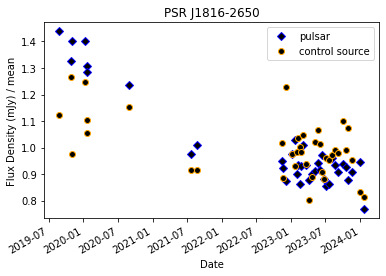

In [28]:
#basically makes a lightcurve, largely copied from 'plot_lightcurves' source code
sigma_thresh=5
figsize = (8, 4)
min_points = 2
min_detections = 0
mjd= False
# TODO: Is this a pd.Timestamp or a datetime?
start_date = None
grid= False
yaxis_start = "0"
peak_flux= True
save = False
outfile = None
use_forced_for_limits = False
use_forced_for_all = False
hide_legend = False
plot_dpi = 150

fig, ax = plt.subplots()

measurements = psr_meas

upper_lim_mask = measurements.detection == False
upper_lims = measurements[upper_lim_mask]

plot_dates = measurements['dateobs']

value_col = err_value_col = 'rms_image'
uplims = True
flux_col = "flux_peak"

marker = "D"
markerfacecolor = 'k'

if upper_lim_mask.any():
        upperlim_points = ax.errorbar(
            plot_dates[upper_lim_mask],
            sigma_thresh *
            upper_lims[value_col],
            yerr=upper_lims[err_value_col],
            uplims=uplims,
            lolims=False,
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            #label=label
        )

detections = measurements[~upper_lim_mask]
marker = 'D'
markerfacecolor = 'k'

if (~upper_lim_mask).any():
        detection_points = ax.errorbar(
            plot_dates[~upper_lim_mask],
            detections[flux_col] / detections[flux_col].mean(),
            #yerr=detections[err_value_col],
            marker=marker,
            c='blue',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            label='pulsar'
        )
        
measurements = ctrl_meas

upper_lim_mask = measurements.detection == False
upper_lims = measurements[upper_lim_mask]

plot_dates = measurements['dateobs']

value_col = err_value_col = 'rms_image'
uplims = True
flux_col = "flux_peak"

marker = "o"
markerfacecolor = 'k'

if upper_lim_mask.any():
        upperlim_points = ax.errorbar(
            plot_dates[upper_lim_mask],
            sigma_thresh *
            upper_lims[value_col],
            yerr=upper_lims[err_value_col],
            uplims=uplims,
            lolims=False,
            marker=marker,
            c='orange',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            #label=label
        )
        
detections = measurements[~upper_lim_mask] 
marker = 'o'
markerfacecolor = 'k'
        
if (~upper_lim_mask).any():
        detection_points = ax.errorbar(
            plot_dates[~upper_lim_mask],
            detections[flux_col] / detections[flux_col].mean(),
            #yerr=detections[err_value_col],
            marker=marker,
            c='orange',
            linestyle="none",
            markerfacecolor=markerfacecolor,
            label='control source'
        )
        
#ax.axhline(psr_meas['flux_peak'].mean(), linestyle='dashed', label='PSR mean flux', color='blue')
#ax.axhline(ctrl_meas['flux_peak'].mean(), linestyle='dashed', label='control mean flux', color='orange')

fig.autofmt_xdate()
ax.set_xlabel('Date')
ax.set_ylabel('Flux Density (mJy) / mean')
name = psr_name
ax.set_title("PSR " + name)
ax.legend()

#plt.savefig('complete_lightcurves/' + name, bbox_inches='tight', pad_inches=2)  # saving to a folder
#date_form = mdates.DateFormatter("%Y-%m-%d")
#ax.xaxis.set_major_formatter(date_form)
#ax.xaxis.set_major_locator(mdates.AutoDateLocator(maxticks=15))

Text(0.5, 1.0, 'PSR J1816-2650')

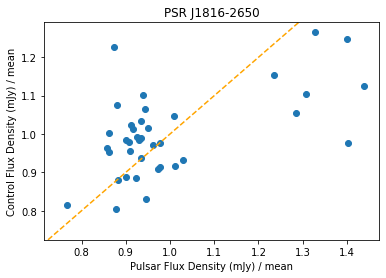

In [27]:
fig, ax = plt.subplots()
flux_col = "flux_peak"
ax.scatter(
    psr_meas[flux_col] / psr_meas[flux_col].mean(),
    ctrl_meas[flux_col] / ctrl_meas[flux_col].mean()
)
ax.axline((0.75,0.75), slope=1, linestyle='dashed', color='orange')
ax.set_ylabel('Control Flux Density (mJy) / mean')
ax.set_xlabel('Pulsar Flux Density (mJy) / mean')
name = psr_name
ax.set_title("PSR " + name)

In [56]:
query_coord = SkyCoord(str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['RAJD']) + " " + str(psr_df[psr_df['JNAME']==psr_name].iloc[0]['DECJD']), unit='deg')
query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
query.find_sources()

Removing source_181635.4-264953.0: Epoch 20 due to missing files
Removing source_181635.4-264953.0: Epoch 21 due to missing files


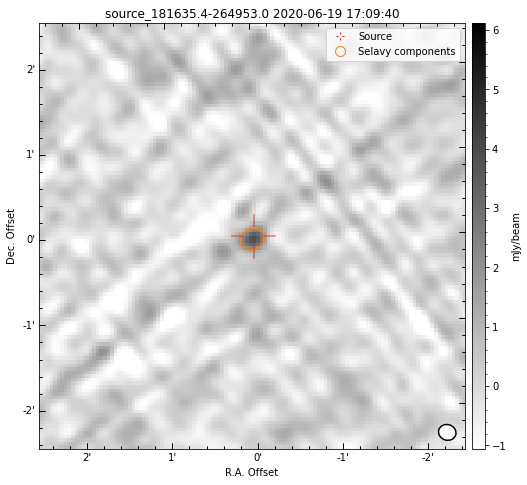

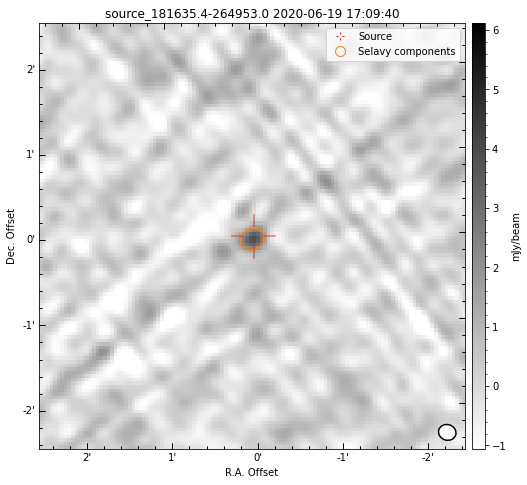

In [57]:
query.results[0].make_png(6)

In [60]:
query_coord = SkyCoord(str(controls_df[controls_df['PSR_assoc']==psr_name].iloc[1]['ra_deg_cont']) + " " + str(controls_df[controls_df['PSR_assoc']==psr_name].iloc[1]['dec_deg_cont']), unit='deg')
query = Query(coords=query_coord, epochs='all-vast', use_tiles=True, corrected_data=False, post_processed_data=False)
query.find_sources()

Removing source_181746.5-270137.7: Epoch 20 due to missing files
Removing source_181746.5-270137.7: Epoch 21 due to missing files


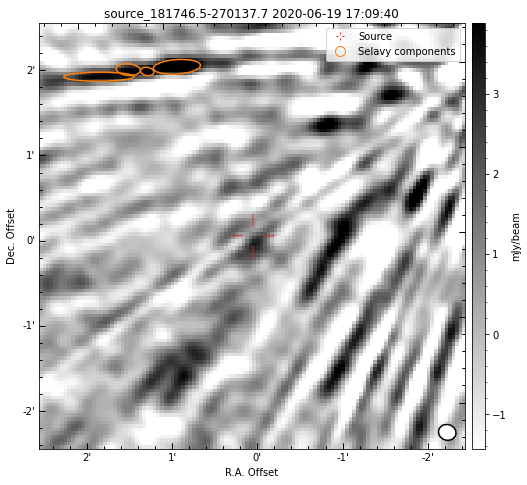

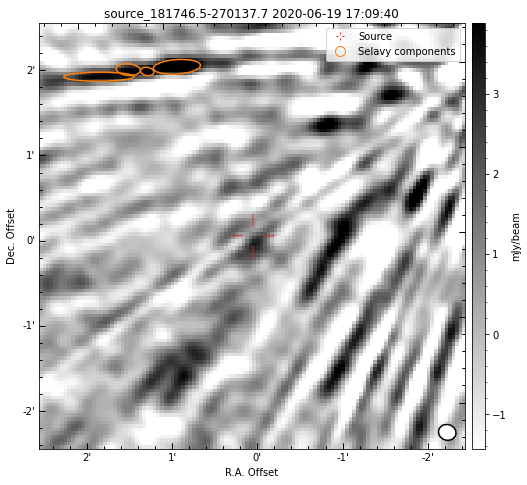

In [55]:
query.results[0].make_png(6)